<a href="https://colab.research.google.com/github/chamm231305/CS4410-Machine-Learning/blob/main/Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import time
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load the MNIST dataset
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X, y = mnist.data, mnist.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset loaded and split.")

def run_logistic_regression(X_train, X_test, y_train, y_test, use_pca=False, n_components=None):
    """Applies StandardScaler, PCA (optional), Logistic Regression, and returns accuracy and time."""
    start_time = time.time()

    # Apply StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if use_pca:
        print(f"Applying PCA with n_components={n_components}...")
        pca = PCA(n_components=n_components)
        X_train_processed = pca.fit_transform(X_train_scaled)
        X_test_processed = pca.transform(X_test_scaled)
        print(f"Original dimensions: {X_train.shape[1]}, Reduced dimensions: {X_train_processed.shape[1]}")
    else:
        print("Training without PCA...")
        X_train_processed = X_train_scaled
        X_test_processed = X_test_scaled

    # Apply Logistic Regression
    print("Training Logistic Regression...")
    logisticRegr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1)
    logisticRegr.fit(X_train_processed, y_train)

    # Get the accuracy score
    y_pred = logisticRegr.predict(X_test_processed)
    accuracy = accuracy_score(y_test, y_pred)

    end_time = time.time()
    elapsed_time = end_time - start_time

    return accuracy, elapsed_time

# --- Without PCA ---
print("\n--- Evaluating Logistic Regression WITHOUT PCA ---")
accuracy_no_pca, time_no_pca = run_logistic_regression(X_train, X_test, y_train, y_test, use_pca=False)
print(f"Accuracy without PCA: {accuracy_no_pca:.4f}")
print(f"Time taken without PCA: {time_no_pca:.2f} seconds")

# --- With PCA ---
print("\n--- Evaluating Logistic Regression WITH PCA (n_components=0.95) ---")
accuracy_pca, time_pca = run_logistic_regression(X_train, X_test, y_train, y_test, use_pca=True, n_components=0.95)
print(f"Accuracy with PCA: {accuracy_pca:.4f}")
print(f"Time taken with PCA: {time_pca:.2f} seconds")

# Compare time
print("\n--- Time Comparison ---")
print(f"Time without PCA: {time_no_pca:.2f} seconds")
print(f"Time with PCA: {time_pca:.2f} seconds")
if time_pca < time_no_pca:
    print(f"PCA reduced training time by {time_no_pca - time_pca:.2f} seconds.")
else:
    print(f"PCA increased training time by {time_pca - time_no_pca:.2f} seconds.")


Loading MNIST dataset...
Dataset loaded and split.

--- Evaluating Logistic Regression WITHOUT PCA ---
Training without PCA...
Training Logistic Regression...
Accuracy without PCA: 0.9154
Time taken without PCA: 47.12 seconds

--- Evaluating Logistic Regression WITH PCA (n_components=0.95) ---
Applying PCA with n_components=0.95...
Original dimensions: 784, Reduced dimensions: 330
Training Logistic Regression...
Accuracy with PCA: 0.9217
Time taken with PCA: 40.60 seconds

--- Time Comparison ---
Time without PCA: 47.12 seconds
Time with PCA: 40.60 seconds
PCA reduced training time by 6.52 seconds.


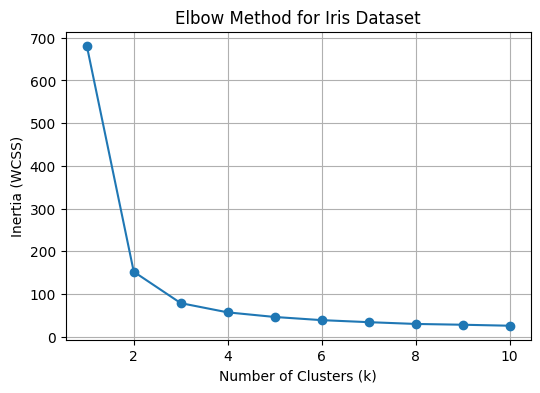

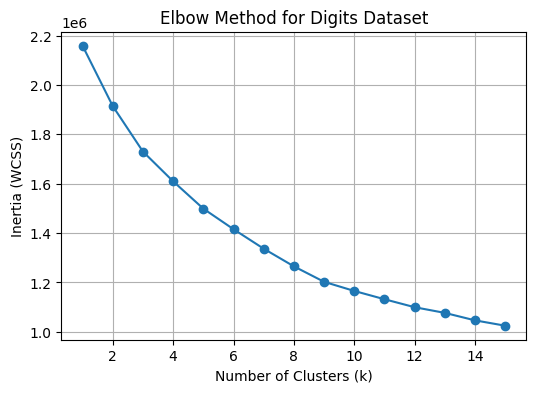

In [4]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits, load_iris


def evaluate_elbow_method(X, dataset_name, max_k=10):
    """Calculates and plots inertia values to evaluate the elbow method."""
    inertia_values = []
    k_range = range(1, max_k + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertia_values.append(kmeans.inertia_)

    # Plot the elbow curve
    plt.figure(figsize=(6, 4))
    plt.plot(k_range, inertia_values, marker="o")
    plt.title(f"Elbow Method for {dataset_name} Dataset")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia (WCSS)")
    plt.grid(True)
    plt.show()


# Load datasets
iris = load_iris()
digits = load_digits()

# Run evaluation
evaluate_elbow_method(iris.data, "Iris")
evaluate_elbow_method(digits.data, "Digits", max_k=15)